# Setup

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/home/sc4422/scratch/watchmal/')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression_variable_multi import (WatChMaLPositionRegression,plot_histograms, plot_resolution_profile,plot_resolution_profile_2d, plot_bias_profile, tabulate_statistics)
# dir only, no fitqun
from analysis.regression_variable_multi import WatChMaLOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-177-g8f8d058-dirty


# Processing h5 data

In [7]:
cds_geo_path = '/home/sc4422/scratch/'

In [8]:
combined_split_path = (
    "/home/sc4422/scratch/wcte_data/combined_single_multi_e_FC_trigger_v2.npz"
)

test_idxs_variable = np.load(
    combined_split_path,
    allow_pickle=True
)["test_idxs"]


single_h5_path = (
    '/scratch/prouse/WCTE_April2026/WCTE_1.5.2_April2026_0-1GeV_3M_e-_3M_mu-_triggerT.h5'
)

multi_h5_path = (
    "/home/sc4422/scratch/simulation/h5/wcte_2e-_indep_vert_indep_energy_12M.h5"
)

single_h5 = h5py.File(single_h5_path, "r")
multi_h5 = h5py.File(multi_h5_path, "r")

# Number of actual events in the single-ring H5.
# This MUST be the same value used when constructing the global split.
n_single = len(single_h5["positions"])

print("n_single:", n_single)
print("combined test events:", len(test_idxs_variable))

n_single: 6000000
combined test events: 270342


In [9]:
def get_values_variable(single_h5, multi_h5, global_idxs, n_single):

    N = len(global_idxs)

    positions = np.full((N, 2, 3), np.nan)
    directions = np.full((N, 2, 3), np.nan)
    angles = np.full((N, 2, 2), np.nan)

    energies = np.full((N, 2), np.nan)
    labels = np.full((N, 2), -1, dtype=int)

    ring_mask = np.zeros((N, 2), dtype=bool)

    nhits = np.zeros(N, dtype=int)
    fc = np.zeros(N, dtype=bool)

    # Useful for debugging / later selections
    source = np.zeros(N, dtype=int)
    local_indices = np.zeros(N, dtype=np.int64)


    # Work out which H5 each global index belongs to

    single_events = global_idxs < n_single
    multi_events = ~single_events

    single_local = global_idxs[single_events]
    multi_local = global_idxs[multi_events] - n_single

    source[multi_events] = 1

    local_indices[single_events] = single_local
    local_indices[multi_events] = multi_local


    # SINGLE-RING EVENTS

    idx = single_local

    pos = np.asarray(single_h5["positions"])[idx]
    ang = np.asarray(single_h5["angles"])[idx]
    ene = np.asarray(single_h5["energies"])[idx]
    lab = np.asarray(single_h5["labels"])[idx]

    # Remove possible single-particle dimension:
    # [N,1,3] -> [N,3]
    if pos.ndim == 3:
        pos = pos[:, 0]

    if ang.ndim == 3:
        ang = ang[:, 0]

    if ene.ndim == 2:
        ene = ene[:, 0]

    if lab.ndim == 2:
        lab = lab[:, 0]

    positions[single_events, 0] = pos
    angles[single_events, 0] = ang
    energies[single_events, 0] = ene
    labels[single_events, 0] = lab

    directions[single_events, 0] = math.direction_from_angles(ang)

    ring_mask[single_events, 0] = True

    hit_index = np.asarray(single_h5["event_hits_index"])
    nhits[single_events] = (
        hit_index[idx + 1] - hit_index[idx]
    )

    fc[single_events] = (
        np.asarray(single_h5["fully_contained"])[idx]
        .squeeze()
        .astype(bool)
    )

    # TWO-RING EVENTS

    idx = multi_local

    pos = np.asarray(multi_h5["positions"])[idx]
    ang = np.asarray(multi_h5["angles"])[idx]
    ene = np.asarray(multi_h5["energies"])[idx]
    lab = np.asarray(multi_h5["labels"])[idx]

    positions[multi_events] = pos
    angles[multi_events] = ang
    energies[multi_events] = ene
    labels[multi_events] = lab

    directions[multi_events] = math.direction_from_angles(ang)

    ring_mask[multi_events] = True

    hit_index = np.asarray(multi_h5["event_hits_index"])
    nhits[multi_events] = (
        hit_index[idx + 1] - hit_index[idx]
    )

    fc[multi_events] = (
        np.asarray(multi_h5["fully_contained"])[idx]
        .squeeze()
        .astype(bool)
    )


    wcte_radius = 159.63
    wcte_half_height = 141.54

    dwall = np.full((N, 2), np.nan)
    towall = np.full((N, 2), np.nan)

    # Only calculate these for real rings
    for slot in range(2):

        valid = ring_mask[:, slot]

        dwall[valid, slot] = math.dwall(
            positions[valid, slot],
            tank_half_height=wcte_half_height,
            tank_radius=wcte_radius,
        )

        towall[valid, slot] = math.towall(
            positions[valid, slot],
            angles[valid, slot],
            tank_half_height=wcte_half_height,
            tank_radius=wcte_radius,
        )


    momentum = np.full((N, 2), np.nan)

    for slot in range(2):
        valid = ring_mask[:, slot]

        momentum[valid, slot] = math.momentum_from_energy(
            energies[valid, slot],
            labels[valid, slot],
        )


    return {
        "angles": angles,
        "energies": energies,
        "positions": positions,
        "labels": labels,
        "directions": directions,

        "ring_mask": ring_mask,

        "nhits": nhits,
        "fc": fc,

        "towall": towall,
        "dwall": dwall,
        "momentum": momentum,

        "global_indices": np.asarray(global_idxs),
        "local_indices": local_indices,
        "source": source,
    }

In [10]:
data_variable = get_values_variable(
    single_h5,
    multi_h5,
    test_idxs_variable,
    n_single,
)

In [11]:
# print(data_variable["positions"].shape)
# print(data_variable["ring_mask"].shape)

# print(
#     "1 ring:",
#     np.sum(data_variable["ring_mask"].sum(axis=1) == 1)
# )

# print(
#     "2 ring:",
#     np.sum(data_variable["ring_mask"].sum(axis=1) == 2)
# )

In [12]:
def sort_two_ring_by_energy(data):

    sorted_data = dict(data)

    two_ring = data["ring_mask"].sum(axis=1) == 2

    order = np.argsort(
        data["energies"][two_ring],
        axis=1,
    )

    per_particle = {
        "angles",
        "energies",
        "positions",
        "labels",
        "directions",
        "momentum",
        "towall",
        "dwall",
        "ring_mask",
    }

    for key in per_particle:

        arr = data[key].copy()
        selected = arr[two_ring]

        idx = order.reshape(
            order.shape
            + (1,) * (selected.ndim - order.ndim)
        )

        arr[two_ring] = np.take_along_axis(
            selected,
            idx,
            axis=1,
        )

        sorted_data[key] = arr

    return sorted_data

In [13]:
data_variable = sort_two_ring_by_energy(data_variable)

# Processing fitQun data

# Making cuts and extracting data

In [14]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [15]:
def apply_cuts_variable(data):

    fc_cut = data["fc"].astype(bool)

    nhits_cut = data["nhits"] > 25

    # A real ring must pass towall.
    # A padded slot is ignored.
    towall_pass_per_slot = (
        (data["towall"] > 100)
        | ~data["ring_mask"]
    )

    towall_cut = towall_pass_per_slot.all(axis=1)

    return (
        fc_cut
        & nhits_cut
        & towall_cut
    )

In [16]:
cuts_variable = apply_cuts_variable(data_variable)

print(cuts_variable.shape)
print("passing:", cuts_variable.sum())

(270342,)
passing: 193667


In [17]:
variable_args = {
    "indices": test_idxs_variable,
    "selection": None,
}

# Loading ResNet results

In [18]:
outdir_reg = "/home/sc4422/scratch/output/regression/multiring/"

In [19]:
### 40 epochs


### PER EVENT
# nhg_10_epoch = 
# nhg_20_epoch = 
# nhg_dirloss =

ht_10_epoch = 'gnn/electrons/hep/2026-08-23/18-34-20-622'
ht_20_epoch = 'gnn/electrons/hep/2026-08-23/22-18-16-339/'
# ht_allthree =

# nhg_variable_position_event = [
#     WatChMaLPositionRegression(directory=outdir_reg + nhg_variable_multi, run_label="NHG 10 epochs", true_positions=data_variable["positions"],ring_mask=data_variable["ring_mask"], true_directions=data_variable["directions"], indices=data_variable["global_indices"],selection = cuts_variable)
# ]

ht_variable_position_event = [
    WatChMaLPositionRegression(directory=outdir_reg + ht_10_epoch, run_label="HT 10 epochs", true_positions=data_variable["positions"],ring_mask=data_variable["ring_mask"], true_directions=data_variable["directions"], indices=data_variable["global_indices"],selection = cuts_variable),
    WatChMaLPositionRegression(directory=outdir_reg + ht_20_epoch, run_label="HT 20 epochs", true_positions=data_variable["positions"],ring_mask=data_variable["ring_mask"], true_directions=data_variable["directions"], indices=data_variable["global_indices"],selection = cuts_variable),
]
### PER PARTICLE

cuts_particle = cuts_variable[ht_variable_position_event[0].particle_event_index]



# Plot training progression

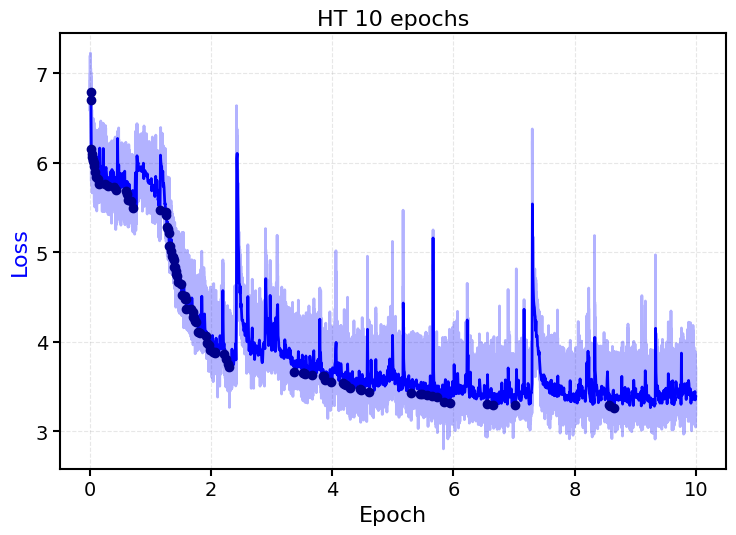

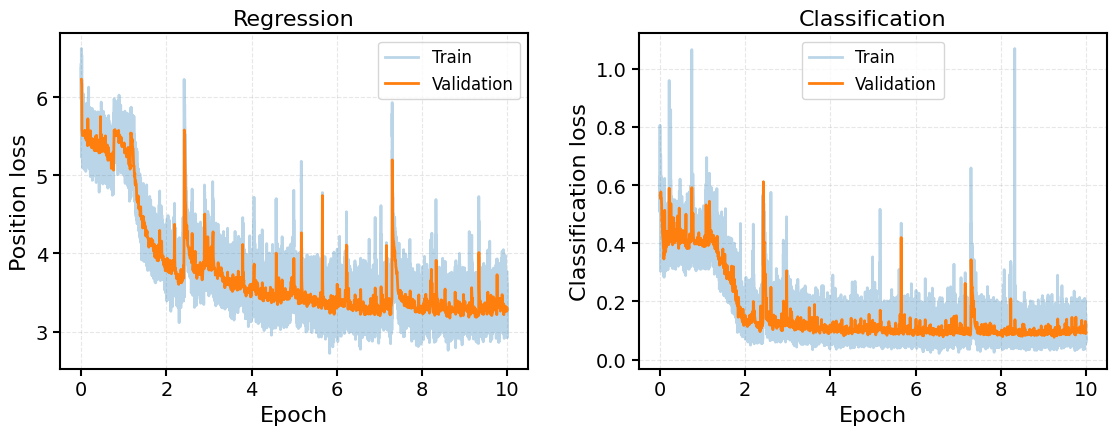

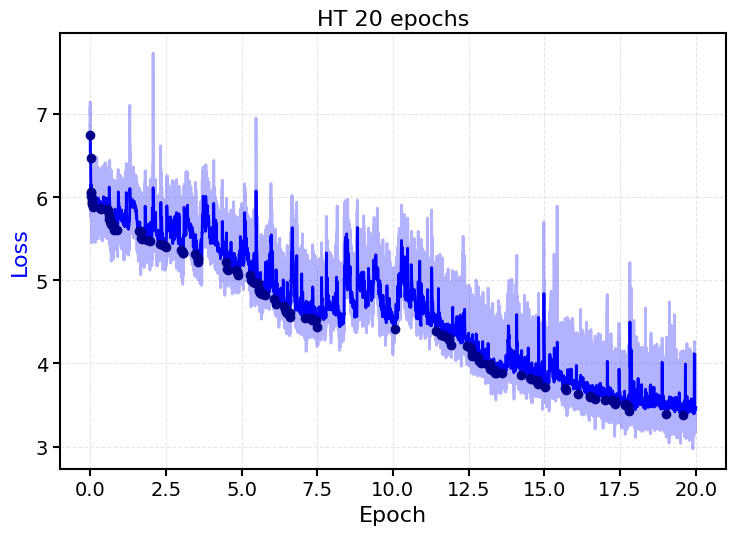

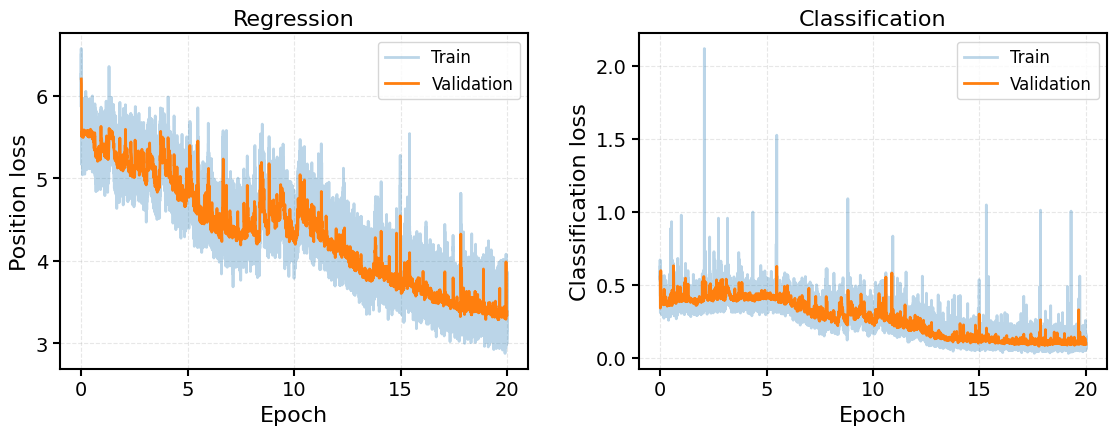

In [20]:
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
#     # ax1.set_ylim(0.1, 100)
#     # ax1.set_xlim(10,)
# for r in resnet_muon_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# # for r in resnet_muon_energy:
# #     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_position:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
    
# for r in e_position_slot_0:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

# for r in e_position_truth_1:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in e_position_mean:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

for r in ht_variable_position_event:
    # Joint loss
    fig, ax = r.plot_training_progression(
        legend=None,
        fig_size=(8, 6),
        title=r.run_label
    )

    # Separate position + classification losses
    fig, axes = r.plot_loss_components(
        fig_size=(12, 5),
        legend='best'
    )
# for r in res_e_position_mean:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in nhg_e_position_mean:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

# Energy and position statistics

In [21]:
tabulate_statistics(
    ht_variable_position_event,
    quantities=[
        "mean_position_3d_error_per_event",
        "single_ring_mean_position_3d_error_per_event",
        "two_ring_mean_position_3d_error_per_event",
    ],
    stat_labels=[
        "Overall position resolution [cm]",
        "Single-ring position resolution [cm]",
        "Two-ring position resolution [cm]",
    ],
    statistic="resolution",
    transpose=True,
)

,Overall position resolution [cm],Single-ring position resolution [cm],Two-ring position resolution [cm]
HT 10 epochs,70.27,47.62,89.66
HT 20 epochs,73.63,50.60,92.01


In [22]:
tabulate_statistics(
    ht_variable_position_event,
    quantities=[
        "ring_count_correct",
        "single_ring_ring_count_correct",
        "two_ring_ring_count_correct",
    ],
    stat_labels=[
        "Overall classification accuracy",
        "Single-ring classification accuracy",
        "Two-ring classification accuracy",
    ],
    statistic="mean",
    transpose=True,
)

,Overall classification accuracy,Single-ring classification accuracy,Two-ring classification accuracy
HT 10 epochs,0.95,0.98,0.91
HT 20 epochs,0.95,0.97,0.92


In [23]:
tabulate_statistics(
    ht_variable_position_event,
    quantities=[
        "mean_position_3d_error_correct_classification",
        "single_ring_mean_position_3d_error_correct_classification",
        "two_ring_mean_position_3d_error_correct_classification",
    ],
    stat_labels=[
        "Overall position resolution (Correctly classified) [cm]",
        "Single-ring position resolution (Correctly classified) [cm]",
        "Two-ring position resolution (Correctly classified) [cm]",
    ],
    statistic="mean",
    transpose=True,
)

,Overall position resolution (Correctly classified) [cm],Single-ring position resolution (Correctly classified) [cm],Two-ring position resolution (Correctly classified) [cm]
HT 10 epochs,57.07,42.20,77.85
HT 20 epochs,59.75,44.42,80.44


In [24]:
# energy_stats = ["momentum_fractional_errors", "momentum_residuals"]
# energy_stat_labels = ["Momentum fractional error resolution", "Momentum residual resolution"]
# energy_stat_types = ['resolution', 'resolution']

energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100

energy_stats = [energy_percentage_errors, momentum_percentage_errors,energy_percentage_errors, momentum_percentage_errors]
# energy_stats = ["energy_fractional_errors", "energy_residuals", 'momentum_residuals', 'momentum_fractional_errors']
energy_stat_labels = ['Energy percentage errors', 'Momentum percentage errors','Energy percentage error (bias)', 'Momentum percentage errors (bias)']
energy_stat_types = ['resolution', 'resolution','mean','mean']

tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)


NameError: name 'resnet_muon_energy' is not defined

In [ ]:
E = np.asarray(data_new_geo['energies'])
print("slot0 higher energy fraction:", (E[:, 0] > E[:, 1]).mean())

pred_sep = np.linalg.norm(raw[:, 0] - raw[:, 1], axis=-1)
true_sep = np.linalg.norm(truth[:, 0] - truth[:, 1], axis=-1)
print("median pred sep:", np.median(pred_sep), "median true sep:", np.median(true_sep))

matched = run.get_outputs("predicted_positions")
print("68th pct:", np.quantile(np.linalg.norm(matched - np.asarray(e_pos_1), axis=-1), 0.68))

print("identical slots:", (raw[:, 0] == raw[:, 1]).all(axis=-1).mean())

In [ ]:
import inspect
import analysis.regression_multiring as reg   # or whatever your import path is
import analysis.read_multiring as rm

print(reg.__file__)   # is this the file you actually edited?
print(inspect.signature(reg.WatChMaLPositionRegression.__init__))   # should show match_truth, anchor
print(inspect.signature(rm.WatChMaLOutput.get_outputs))             # should show apply_swap, select_ring

In [ ]:
run = WatChMaLPositionRegression(outdir_reg + ht_mse, 1, "HT Ring 1", e_pos_1, e_dir_1,
                                 **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args)

print("swap fraction:", run.swap.mean())

raw = run.get_outputs("predicted_positions", apply_swap=False, select_ring=False)
truth = np.asarray(data_new_geo['positions'])
print("preds:", raw.shape, "truth:", truth.shape)          # both (N, 2, 3), same N
print("pred range:", raw.min(), raw.max())
print("truth range:", truth.min(), truth.max())            # should be same units/scale!
print("e_pos_1 matches truth[:,1]:", np.allclose(np.asarray(e_pos_1), truth[:, 1]))

In [ ]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

In [ ]:
import copy

resnet_e_energy_clipped = copy.deepcopy(resnet_e_energy)

for r in resnet_e_energy_clipped:
    pred = np.asarray(r.predictions).squeeze()
    physical_mask = pred >= 0.511
    existing = np.zeros(len(pred), dtype=bool)
    existing[r.selection] = True
    r.selection = existing & physical_mask

tabulate_statistics(resnet_e_energy_clipped, energy_stats, energy_stat_labels, energy_stat_types)

In [ ]:
def nan_summary(r, name, mass=0.511):
    pred = np.asarray(r.predictions).squeeze()
    sel = r.selection
    if sel is not None:
        pred = pred[sel]
    print(f"{name:40s}  below_mass: {np.mean(pred < mass):.7f}  nan: {np.mean(~np.isfinite(pred)):.4f}  pred_min: {pred.min():.3f}")

for i, r in enumerate(resnet_e_energy):
    nan_summary(r, str(i))
    
fig, axes = plt.subplots(1, len(resnet_e_energy), figsize=(15, 7), squeeze=False)
axes = axes.flatten()

for i, (r, ax) in enumerate(zip(resnet_e_energy, axes)):
    pred = np.asarray(r.predictions).squeeze()[r.selection]
    below = pred[pred < 0.511]
    if len(below) > 0:
        ax.hist(below, bins=50)
        ax.set_xlabel("Predicted energy [MeV]")
        ax.set_ylabel("Count")
        ax.set_title('Distribution of predicted energies below the electron mass')
    else:
        ax.text(0.5, 0.5, "none", transform=ax.transAxes, ha='center')
        ax.set_title(f"[{i}]")

fig.tight_layout()
plt.show()

In [ ]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)



In [ ]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

In [ ]:
print(test_idxs_new_geo.shape)

In [ ]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_muon_direction, dir_stats, dir_stat_labels, dir_stat_types)

In [ ]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_e_direction, dir_stats, dir_stat_labels, dir_stat_types)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
coords = ['x', 'y', 'z']
residuals = [r.x_residuals, r.y_residuals, r.z_residuals]

r = resnet_e_position[8]  # pick whichever model, e.g. HGT

for i, (coord, res) in enumerate(zip(coords, residuals)):
    t = r.true_positions[:, i]
    p = r.position_prediction[:, i]
    res = getattr(r, f'{coord}_residuals')
    
    # scatter: predicted vs true
    axes[0, i].scatter(t, p, alpha=0.05, s=1)
    lim = [min(t.min(), p.min()), max(t.max(), p.max())]
    axes[0, i].plot(lim, lim, 'r--', lw=1)
    axes[0, i].set_xlabel(f'True {coord} [cm]')
    axes[0, i].set_ylabel(f'Predicted {coord} [cm]')
    axes[0, i].set_title(f'{coord} scatter')
    
    # residual histogram
    axes[1, i].hist(res[r.selection], bins=100, density=True, histtype='step', lw=2)
    axes[1, i].axvline(0, color='r', lw=1)
    axes[1, i].set_xlabel(f'Predicted - True {coord} [cm]')
    axes[1, i].set_title(f'{coord} residual (std={res[r.selection].std():.1f} cm)')

plt.suptitle(r.run_label)
plt.tight_layout()
plt.show()

In [ ]:
print(data_new_geo['energies'].shape)
print(test_idxs_new_geo.shape)
print(e_idxs_new_geo)
print(len(e_idxs_new_geo))

In [ ]:
# energy investigation


# e_idx = test_idxs_new_geo[e_idxs_new_geo]
# e_mom_binning       = get_binning(data_new_geo["momentum"][e_idx], 20, 0, 1000)
# e_cos_zenith_binning = get_binning(np.cos(data_new_geo["angles"][e_idx, 0]), 20, -1, 1)
# e_azimuth_binning   = get_binning(data_new_geo["angles"][e_idx, 1] * 180 / np.pi, 20, -180, 180)
# e_dwall_binning      = get_binning(data_new_geo["dwall"][e_idx], 22, 50, 300)
# e_towall_binning     = get_binning(data_new_geo["towall"][e_idx], 30, 50, 800)


e_mom_binning_0       = get_binning(data_new_geo["momentum"][:,0], 20)
e_cos_zenith_binning_0 = get_binning(np.cos(data_new_geo["angles"][:,0][:, 0]), 20)
e_azimuth_binning_0    = get_binning(data_new_geo["angles"][:,0][:, 1] * 180 / np.pi, 20)
e_dwall_binning_0      = get_binning(data_new_geo["dwall"][:,0], 22)
e_towall_binning_0     = get_binning(data_new_geo["towall"][:,0], 30)

e_mom_binning_1       = get_binning(data_new_geo["momentum"][:,1], 20)
e_cos_zenith_binning_1 = get_binning(np.cos(data_new_geo["angles"][:,1][:, 0]), 20)
e_azimuth_binning_1    = get_binning(data_new_geo["angles"][:,1][:, 1] * 180 / np.pi, 20)
e_dwall_binning_1      = get_binning(data_new_geo["dwall"][:,1], 22)
e_towall_binning_1     = get_binning(data_new_geo["towall"][:,1], 30)

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

# below_mass_quantity = lambda r: (np.asarray(r.predictions).squeeze() < 0.511).astype(float)

# for r in resnet_e_energy:
#     plot_bias_profile([r], below_mass_quantity, e_mom_binning,    ax=axes[0], y_lim=(0,0.0002), x_label="True electron momentum [MeV]", y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_towall_binning, ax=axes[1],  y_lim=(0,0.0002), x_label="Distance to wall [cm]",        y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_dwall_binning,  ax=axes[2], y_lim=(0,0.0002), x_label="Distance from wall [cm]",      y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_cos_zenith_binning,  ax=axes[3], y_lim=(0,0.0002), x_label="Cos zenith angle",      y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_azimuth_binning,  ax=axes[4], y_lim=(0,0.0002), x_label="Azimuth angle",      y_label="Fraction below electron mass", legend=None)

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, 1.02))
# fig.tight_layout()
# plt.show()

In [ ]:
edges, idx = e_mom_binning_0
e_mom_binning_0_overall = (edges, np.concatenate((idx, idx)))

edges, idx = e_mom_binning_1
e_mom_binning_1_overall = (edges, np.concatenate((idx, idx)))

In [ ]:
### multiring cases

# vertex separation

true_sep = np.linalg.norm(data_new_geo['positions'][:, 0] - data_new_geo['positions'][:, 1], axis=1)
true_sep_binning = get_binning(true_sep, 20)
edges, idx = true_sep_binning

true_sep_binning_overall = (edges, np.concatenate((idx, idx)))

# opening angle

opening_angle = np.degrees(np.arccos(np.clip(np.sum(data_new_geo['directions'][:, 0] * data_new_geo['directions'][:, 1], axis=1), -1, 1)))
opening_angle_binning = get_binning(opening_angle, 20)
edges, idx = opening_angle_binning
opening_angle_binning_overall = (edges, np.concatenate((idx, idx)))


# energy difference 

e_diff = data_new_geo['energies'][:, 1] - data_new_geo['energies'][:, 0]
e_diff_binning = get_binning(e_diff, 20)


## energy ratio

e_ratio = data_new_geo['energies'][:, 1] / data_new_geo['energies'][:, 0]
log_e_ratio = np.log(e_ratio)
log_e_ratio_binning = get_binning(log_e_ratio, 20)
edges, idx = log_e_ratio_binning
log_e_ratio_binning_overall = (edges, np.concatenate((idx, idx)))


In [ ]:
for name, binning in [('mom', e_mom_binning), ('towall', e_towall_binning), ('dwall', e_dwall_binning), 
                       ('cos_zenith', e_cos_zenith_binning), ('azimuth', e_azimuth_binning)]:
    print(name, binning[0].min(), binning[0].max())

In [ ]:
# in your notebook, after you've defined the dataset
dataset = GNNMultiPMTDataset(h5file=..., geometry_file=..., k_neighbors=...)

print("shape:", dataset.mpmt_positions.shape)
print("mean per axis:", dataset.mpmt_positions.mean(axis=1))
print("std per axis:", dataset.mpmt_positions.std(axis=1))
print("min per axis:", dataset.mpmt_positions.min(axis=1))
print("max per axis:", dataset.mpmt_positions.max(axis=1))

# Energy and position plots

In [ ]:
# # can add y_lim for the y axis


# all_runs_pos = e_position_truth_0 ## must use truth for truth binning

# figs, axes = plt.subplots(3,2, figsize=(15, 15))
# for r in all_runs_pos:
#     plot_resolution_profile([r], 'position_3d_errors', e_towall_binning_0, ax=axes[0,0],y_lim=(0,80), x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
#     plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning_0, ax=axes[0,1], y_lim=(0,80),x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
#     plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning_0, ax=axes[1,0], y_lim=(0,80),x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
#     plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning_0,ax=axes[1,1],y_lim=(0,80),x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
#     plot_resolution_profile([r],'position_3d_errors',e_mom_binning_0, ax=axes[2,0],y_lim=(0,80),x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None)

In [ ]:
# all_runs_mom =  resnet_e_energy #+ [fitqun_e]

# figs, axes = plt.subplots(3,2, figsize=(15, 15))
# for r in all_runs_mom:
#     plot_resolution_profile([r], 'momentum_residuals', e_towall_binning, ax=axes[0,0], y_lim = (10,30), x_label="Distance to detector wall [cm]", y_label="Energy resolution",legend=None)
#     plot_resolution_profile([r], 'momentum_residuals', e_dwall_binning, ax=axes[0,1],  y_lim = (10,30),x_label="Distance from detector wall [cm]",y_label="Energy resolution",legend=None)
#     plot_resolution_profile([r],'momentum_residuals', e_cos_zenith_binning, ax=axes[1,0],  y_lim = (10,30),x_label="Cosine of Zenith", y_label="Energy resolution", legend=None)
#     plot_resolution_profile([r],'momentum_residuals',e_azimuth_binning,ax=axes[1,1], y_lim = (10,30),x_label="Azimuth",y_label="Energy resolution",legend=None)
#     plot_resolution_profile([r],'momentum_residuals', e_mom_binning, ax=axes[2,0], y_lim = (10,30),x_label="True electron momentum [MeV]",y_label="Energy resolution",legend=None)

In [ ]:
# all_runs_dir =  resnet_e_direction #+ [fitqun_e]

# figs, axes = plt.subplots(3,2, figsize=(15, 15))
# for r in all_runs_dir:
#     plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], y_lim =(3,15), x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
#     plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1],  y_lim =(3,15),x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
#     plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0],  y_lim =(3,15),x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
#     plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1], y_lim =(3,15),x_label="Azimuth",y_label="Direction Momentum",legend=None)
#     plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0], y_lim =(3,15),x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)

In [ ]:
# ### 2 particle plots

# # all_runs_pos = e_position_slot_0 + e_position_slot_1

# n_colours = len(e_position_truth_0)
# colours = plt.cm.tab10(np.linspace(0, 1, n_colours))

# figs, axes = plt.subplots(3,2, figsize=(15, 15))
# for n, r in enumerate(e_position_truth_0):
# #     plot_resolution_profile([r], 'position_3d_errors', e_towall_binning_0, ax=axes[0,0],y_lim=(0,80), x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None, marker='s', color = colours[n])
# #     plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning_0, ax=axes[0,1], y_lim=(0,80),x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None, marker='s', color = colours[n])
# #     plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning_0, ax=axes[1,0], y_lim=(0,80),x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None, marker='s', color = colours[n])
# #     plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning_0,ax=axes[1,1],y_lim=(0,80),x_label="Azimuth",y_label="Position resolution [cm]",legend=None, marker='s', color = colours[n])
#     plot_resolution_profile([r],'position_3d_errors',e_mom_binning_0, ax=axes[2,0],y_lim=(0,120),x_label="Particle 0 true electron momentum [MeV]",y_label="Position resolution [cm]",legend='best', marker='', color = colours[n])
# for n, r in enumerate(e_position_truth_1):
# #     plot_resolution_profile([r], 'position_3d_errors', e_towall_binning_1, ax=axes[0,0],y_lim=(0,80), x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None, color = colours[n])
# #     plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning_1, ax=axes[0,1], y_lim=(0,80),x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None, color = colours[n])
# #     plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning_1, ax=axes[1,0], y_lim=(0,80),x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None, color = colours[n])
# #     plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning_1,ax=axes[1,1],y_lim=(0,80),x_label="Azimuth",y_label="Position resolution [cm]",legend=None, color = colours[n])
#     plot_resolution_profile([r],'position_3d_errors',e_mom_binning_1, ax=axes[2,1],y_lim=(0,120),x_label="Particle 1 true electron momentum [MeV]",y_label="Position resolution [cm]",legend='best', marker='',color = colours[n])


In [ ]:
### 2 particle plots
### 2 particle plots

# all_runs_pos = e_position_slot_0 + e_position_slot_1
import matplotlib as mpl

science_rc = {
    # font
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],  # Times if available, else fallback
    "mathtext.fontset": "dejavuserif",

    # ticks: inward, on all sides, with minor ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,

    # axes / lines
    "axes.linewidth": 0.5,
    "grid.linewidth": 0.5,
    "lines.linewidth": 1.0,
    "axes.grid": False,

    # legend
    "legend.frameon": False,

    # figure
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
}

# all_runs_pos = e_position_slot_0 + e_position_slot_1

n_colours = len(e_position_mean)

with mpl.rc_context(science_rc):
    colours = plt.cm.tab10(np.linspace(0, 1, n_colours))

    figs, axes = plt.subplots(3,2, figsize=(15, 15))
    for n, r in enumerate(e_position_mean):
        plot_resolution_profile([r],'position_3d_errors',e_mom_binning_0_overall, ax=axes[2,0],y_lim=(0,90),x_label="True electron momentum of lower energy particle [MeV]",y_label="Position resolution [cm]",legend='best', marker='', color = colours[n])
        plot_resolution_profile([r],'position_3d_errors',e_mom_binning_1_overall, ax=axes[2,1],y_lim=(0,90),x_label="Particle 1 true electron momentum [MeV]",y_label="Position resolution [cm]",legend='best', marker='',  color = colours[n])

    


In [ ]:
### 2 particle plots



n_colours = len(e_position_mean)

with mpl.rc_context(science_rc):
    colours = plt.cm.tab10(np.linspace(0, 1, n_colours))
    figs, axes = plt.subplots(3,2, figsize=(15, 15))
    for n, r in enumerate(e_position_mean):
        plot_resolution_profile([r], 'position_3d_errors', true_sep_binning_overall, ax=axes[0,0],y_lim=(0,130), x_label="True separation [cm]", y_label="Position resolution [cm]",legend='best', marker='', color = colours[n])
        plot_resolution_profile([r], 'position_3d_errors', opening_angle_binning_overall, ax=axes[1,0],y_lim=(0,130), x_label="Opening angle [°]", y_label="Position resolution [cm]",legend='best', marker='', color = colours[n])
        plot_resolution_profile([r], 'position_3d_errors', log_e_ratio_binning_overall, ax=axes[0,1],y_lim=(0,130), x_label="$\log(E_\mathrm{high}/E_\mathrm{low})$", y_label="Position resolution [cm]",legend='best', marker='', color = colours[n])


In [ ]:
n_colours = len(e_position_truth_0)
colours = plt.cm.tab10(np.linspace(0, 1, n_colours))

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for n, r in enumerate(e_position_truth_0):
    plot_resolution_profile([r], 'position_3d_errors', true_sep_binning, ax=axes[0,0],y_lim=(0,150), x_label="true_sep_binning[cm]", y_label="Position resolution [cm]",legend='best', marker='s', color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors', opening_angle_binning, ax=axes[0,1],y_lim=(0,150), x_label="opening_angle_binning", y_label="Position resolution [cm]",legend='best', marker='s', color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors', e_diff_binning, ax=axes[1,0],y_lim=(0,150), x_label="e_diff_binning", y_label="Position resolution [cm]",legend='best', marker='s', color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors', e_ratio_binning, ax=axes[1,1],y_lim=(0,150), x_label="e_ratio_binning", y_label="Position resolution [cm]",legend='best', marker='s', color = colours[n])
for n, r in enumerate(e_position_truth_1):
    plot_resolution_profile([r], 'position_3d_errors', true_sep_binning, ax=axes[0,0],y_lim=(0,150), x_label="true_sep_binning [cm]", y_label="Position resolution [cm]",legend='best', color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors', opening_angle_binning, ax=axes[0,1],y_lim=(0,150), x_label="opening_angle_binning", y_label="Position resolution [cm]",legend='best', color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors', e_diff_binning, ax=axes[1,0],y_lim=(0,150), x_label="e_diff_binning", y_label="Position resolution [cm]",legend='best', color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors', e_ratio_binning, ax=axes[1,1],y_lim=(0,150), x_label="e_ratio_binning", y_label="Position resolution [cm]",legend='best', color = colours[n])

    

In [ ]:
### 2D histogram 


# r = e_position_truth_0[3]
# preds = r.position_prediction

# sel = r.selection

# print(r.position_prediction)
# print(r.get_outputs("predicted_positions", select_ring=True, concatenate= False)) # same


# true_sep_binning # bin array, indices
# opening_angle_binning # bin array, indices


figs, axes = plt.subplots(3,2, figsize=(15, 15))
for n, r in enumerate(e_position_truth_0):
    plot_resolution_profile_2d([r], 'position_3d_errors', true_sep_binning, opening_angle_binning)

    

# data = values[selection]
# data_bins = binning[1][selection]
# return [data[data_bins == b] for b in range(1, binning[0].size)]


In [ ]:
e_position_truth_0[1].ring = None
pred_positions = e_position_truth_0[1].get_outputs("predicted_positions", select_ring=True, concatenate= False)


true_pos_high = data_new_geo['positions'][:,1]
true_pos_low = data_new_geo['positions'][:,0]


pred_pos_high = pred_positions[:,1]
pred_pos_low = pred_positions[:,0]

low_to_high = true_pos_high - true_pos_low
unit_low_to_high = low_to_high / np.clip(
    np.linalg.norm(low_to_high, axis=1, keepdims=True),
    1e-8,
    None,
)

low_residual = pred_pos_low - true_pos_low

low_error_toward_high = np.sum(
    low_residual * unit_low_to_high,
    axis=1,
)

high_to_low = true_pos_low - true_pos_high
unit_high_to_low = high_to_low / np.clip(
    np.linalg.norm(high_to_low, axis=1, keepdims=True),
    1e-8,
    None,
)

high_residual = pred_pos_high - true_pos_high

high_error_toward_low = np.sum(
    high_residual * unit_high_to_low,
    axis=1,
)
def pull_summary(name, pull):
    print(name)
    print("  Mean signed pull:", np.mean(pull))
    print("  Median signed pull:", np.median(pull))
    print("  Fraction positive:", np.mean(pull > 0))
    print("  68% absolute:", np.quantile(np.abs(pull), 0.68))

pull_summary("Low toward high", low_error_toward_high)
pull_summary("High toward low", high_error_toward_low)

In [ ]:

separate_heads = e_position_truth_0[1]
slot_comp = e_position_truth_0[0]
both = e_position_truth_0[2]
#


for model in [separate_heads, slot_comp, both]:
    model.ring = None

# Predictions
pred_sep = separate_heads.get_outputs(
    "predicted_positions",
    select_ring=True,
    concatenate=False,
)

pred_comp = slot_comp.get_outputs(
    "predicted_positions",
    select_ring=True,
    concatenate=False,
)

pred_both = both.get_outputs(
    "predicted_positions",
    select_ring=True,
    concatenate=False,
)

# Truth
true_positions = data_new_geo["positions"]

# Per-ring position errors
sep_err_0 = np.linalg.norm(pred_sep[:, 0] - true_positions[:, 0], axis=1)
sep_err_1 = np.linalg.norm(pred_sep[:, 1] - true_positions[:, 1], axis=1)

comp_err_0 = np.linalg.norm(pred_comp[:, 0] - true_positions[:, 0], axis=1)
comp_err_1 = np.linalg.norm(pred_comp[:, 1] - true_positions[:, 1], axis=1)

both_err_0 = np.linalg.norm(pred_both[:, 0] - true_positions[:, 0], axis=1)
both_err_1 = np.linalg.norm(pred_both[:, 1] - true_positions[:, 1], axis=1)

# Pool both rings
sep_err = np.concatenate((sep_err_0, sep_err_1))
comp_err = np.concatenate((comp_err_0, comp_err_1))
both_err = np.concatenate((both_err_0, both_err_1))

# Use your existing opening-angle binning
edges, idx = opening_angle_binning_overall

for i in range(len(edges) - 1):
    mask = idx == i

    if mask.sum() == 0:
        continue

    sep_68 = np.quantile(sep_err[mask], 0.68)
    comp_68 = np.quantile(comp_err[mask], 0.68)
    both_68 = np.quantile(both_err[mask], 0.68)

    best_individual = min(sep_68, comp_68)

    print(
        f"{edges[i]:.1f}-{edges[i+1]:.1f} deg | "
        f"N={mask.sum()} | "
        f"separate={sep_68:.2f} | "
        f"competition={comp_68:.2f} | "
        f"both={both_68:.2f} | "
        f"both-best={both_68 - best_individual:+.2f}"
    )

In [ ]:
import numpy as np

# --------------------------------------------------
# Models
# --------------------------------------------------

models = {
    "separate": e_position_truth_0[1],
    "competition": e_position_truth_0[0],
    "both": e_position_truth_0[2],
}

true_positions = data_new_geo["positions"]
true_energies = data_new_geo["energies"]

# Assuming ring 1 = high energy and ring 0 = low energy in your dataset
true_pos_low = true_positions[:, 0]
true_pos_high = true_positions[:, 1]


# --------------------------------------------------
# Check which truth particle each raw slot is closest to
# BEFORE permutation matching
# --------------------------------------------------

for name, model in models.items():

    model.ring = None

    pred_positions = model.get_outputs(
        "predicted_positions",
        select_ring=False,
        concatenate=False,
    )

    pred_slot0 = pred_positions[:, 0]
    pred_slot1 = pred_positions[:, 1]

    # Distance of each predicted slot to each truth particle
    slot0_to_low = np.linalg.norm(
        pred_slot0 - true_pos_low,
        axis=1,
    )

    slot0_to_high = np.linalg.norm(
        pred_slot0 - true_pos_high,
        axis=1,
    )

    slot1_to_low = np.linalg.norm(
        pred_slot1 - true_pos_low,
        axis=1,
    )

    slot1_to_high = np.linalg.norm(
        pred_slot1 - true_pos_high,
        axis=1,
    )

    # Total assignment costs
    #
    # identity:
    # slot 0 -> low
    # slot 1 -> high
    identity_cost = slot0_to_low + slot1_to_high

    # swapped:
    # slot 0 -> high
    # slot 1 -> low
    swap_cost = slot0_to_high + slot1_to_low

    use_swap = swap_cost < identity_cost

    # --------------------------------------------------
    # Slot-role statistics
    # --------------------------------------------------

    fraction_slot0_low = np.mean(~use_swap)
    fraction_slot0_high = np.mean(use_swap)

    fraction_slot1_low = np.mean(use_swap)
    fraction_slot1_high = np.mean(~use_swap)

    swap_fraction = np.mean(use_swap)

    # How strongly does one assignment dominate?
    assignment_margin = np.abs(identity_cost - swap_cost)

    print(f"\n{name.upper()}")
    print("-" * 40)

    print(f"Swap fraction:               {swap_fraction:.3f}")

    print(f"Slot 0 -> low energy:        {fraction_slot0_low:.3f}")
    print(f"Slot 0 -> high energy:       {fraction_slot0_high:.3f}")

    print(f"Slot 1 -> low energy:        {fraction_slot1_low:.3f}")
    print(f"Slot 1 -> high energy:       {fraction_slot1_high:.3f}")

    print(
        f"Mean assignment margin:      "
        f"{np.mean(assignment_margin):.2f}"
    )

    print(
        f"Median assignment margin:    "
        f"{np.median(assignment_margin):.2f}"
    )

In [ ]:
from matplotlib.ticker import MaxNLocator, LogLocator
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx] 


# instead of using the filtered muons list (from get quantities), im using all and then applying both the muon and the physical cuts as a selection filter (when binning) - therefore the baseline dimension is just the common events between h5 and fitqun

# resnet_muon_position = WatChMaLPositionRegression(
#     outdir_reg + output_pos,
#     "ResNet50 QT+mPMT_pos",
#     true_positions=data_new_geo["positions"][h5_keep_idx],
#     true_directions=data_new_geo["directions"][h5_keep_idx],
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )


resnet_muon_direction = WatChMaLPositionRegression(
    outdir_reg + output_dir,
    "ResNet50 QT+mPMT_pos",
    true_positions=data_new_geo["positions"][h5_keep_idx],
    true_directions=data_new_geo["directions"][h5_keep_idx],
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_mask_h5
)

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
#     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
#     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
#     true_labels=2,                        
#     indices=fq_keep_idx[mu_mask_h5],       
#     selection=None,
# )


muon_mom_binning = [
    get_binning(data_new_geo["momentum"][h5_keep_idx], 20, 0, 1000),
    get_binning(data_new_geo["momentum"][h5_keep_idx][mu_mask_h5], 20, 0, 1000),
]

muon_cos_zenith_binning = [
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0]), 20, -1, 1),
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0][mu_mask_h5]), 20, -1, 1),
]

muon_azimuth_binning = [
    get_binning(data_new_geo["angles"][h5_keep_idx, 1] * 180 / np.pi, 20, -180, 180),
    get_binning(data_new_geo["angles"][h5_keep_idx, 1][mu_mask_h5] * 180 / np.pi, 20, -180, 180),
]

muon_dwall_binning = [
    get_binning(data_new_geo["dwall"][h5_keep_idx], 22, 50, 300),
    get_binning(data_new_geo["dwall"][h5_keep_idx][mu_mask_h5], 22, 50, 300),
]

muon_towall_binning = [
    get_binning(data_new_geo["towall"][h5_keep_idx], 30, 50, 800),
    get_binning(data_new_geo["towall"][h5_keep_idx][mu_mask_h5], 30, 50, 800),
]
all_runs_pos = [resnet_muon_direction, fitqun_mu]

for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)


# fig1, ax1 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_towall_binning[r],       
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax1.set_title("Muon 3D Position Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()

# handles, labels = ax1.get_legend_handles_labels()


# fig2, ax2 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax2.set_title("Muon 3D Position Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()

# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax3.set_title("Muon 3D Position Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()

# handles, labels = ax3.get_legend_handles_labels()


# fig4, ax4 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax4.set_title("Muon 3D Position Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()

# handles, labels = ax4.get_legend_handles_labels()


# fig5, ax5 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon momentum [MeV]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon 3D Position Resolution vs Momentum", fontsize=16)
# fig5.tight_layout()

# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()


In [ ]:

# labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# # mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
# # mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx]

# resnet_muon_energy = WatChMaLEnergyRegression(
#     outdir_reg + output_energy,             
#     "ResNet50 QT+mPMT_E",
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],   
#     true_labels=labels,                                  
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )

# # fitqun_mu = FitQun1ParticleFit(
# #     fq,
# #     "fiTQun",
# #     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
# #     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
# #     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
# #     true_labels=2,
# #     indices=fq_keep_idx[mu_mask_h5],
# #     selection=None,
# # )

# all_runs_pos = [resnet_muon_energy, fitqun_mu]

# fig1, ax1 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_towall_binning[r],
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax1.set_title("Muon Energy Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()
# handles, labels = ax1.get_legend_handles_labels()

# fig2, ax2 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax2.set_title("Muon Energy Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()
# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax3.set_title("Muon Energy Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()
# handles, labels = ax3.get_legend_handles_labels()

# fig4, ax4 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax4.set_title("Muon Energy Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()
# handles, labels = ax4.get_legend_handles_labels()

# fig5, ax5 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon energy [MeV]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon Energy Resolution vs Energy", fontsize=16)
# fig5.tight_layout()
# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()

In [ ]:
true_delta = true_pos_high - true_pos_low
pred_delta = pred_pos_high - pred_pos_low

true_sep = np.linalg.norm(true_delta, axis=1)
pred_sep = np.linalg.norm(pred_delta, axis=1)

sep_ratio = pred_sep / np.clip(true_sep, 1e-8, None)

cos_angle = np.sum(pred_delta * true_delta, axis=1) / (
    pred_sep * true_sep + 1e-8
)

delta_angle_error = np.degrees(
    np.arccos(np.clip(cos_angle, -1, 1))
)

print("Median separation ratio:", np.median(sep_ratio))
print("68% separation ratio:", np.quantile(sep_ratio, 0.68))
print("Fraction with separation < half truth:", np.mean(sep_ratio < 0.5))

print("Median pair-axis angle error:", np.median(delta_angle_error))
print("68% pair-axis angle error:", np.quantile(delta_angle_error, 0.68))


# check this for the non query pos case

In [ ]:
inward_contraction = (
    low_error_toward_high
    + high_error_toward_low
)

print("Mean inward contraction:",
      np.mean(inward_contraction))

print("Median inward contraction:",
      np.median(inward_contraction))

print("68% inward contraction:",
      np.quantile(inward_contraction, 0.68))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- runs ----
separation_runs = [WatChMaLPositionRegression(outdir_reg + ht_huber, None, "HT Baseline", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
WatChMaLPositionRegression(outdir_reg + ht_auxloss_qpos, None, "HT Reinjection + Auxiliary Loss", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# WatChMaLPositionRegression(outdir_reg + resnet_qpos_auxloss, None, "ResNet", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
]

# ---- separation computation ----
def ring_separation(run, true_positions_full):
    """Return (pred_sep, true_sep) in cm, selection-applied."""
    run.ring = 0
    p0 = run.get_outputs("predicted_positions", select_ring=True, concatenate= False)
    run.ring = 1
    p1 = run.get_outputs("predicted_positions", select_ring=True, concatenate= False)

    pred_sep = np.linalg.norm(p0 - p1, axis=1)
    true_sep = np.linalg.norm(true_positions_full[:, 0] - true_positions_full[:, 1], axis=1)
    return pred_sep[run.selection], true_sep[run.selection]


In [ ]:
opening_angle = np.degrees(np.arccos(
    np.clip(np.sum(dir_0 * dir_1, axis=1), -1, 1)
))

def opening_angle(run, true_directions):
    dir_0_true = 
    dir_1_true = 
    
    run.ring = 0 
    dir_0_pred = run.get_outputs("predicted_directions", select_ring=True, concatenate=False)
    dir_1_pred = 
    
    opening_angle_true = np.degrees(np.arccos(
        np.clip(np.sum(dir_0_true * dir_1_true, axis=1), -1, 1)
    ))
    
    opening_angle_pred = np.degrees(np.arccos(
        np.clip(np.sum(dir_0_pred * dir_1_pred, axis=1), -1, 1)
    ))
    

In [ ]:
# ---- plots ----

with mpl.rc_context(science_rc):
    fig, axes = plt.subplots(1, len(separation_runs), figsize=(12, 5), sharex=True, sharey=True)
    for ax, run in zip(axes, separation_runs):
        pred_sep, true_sep = ring_separation(run, data_new_geo['positions'])
        ax.hist(true_sep, bins=100, histtype='step', label='True', density=True)
        ax.hist(pred_sep, bins=100, histtype='step', label='Predicted', density=True)
        res = np.quantile(np.abs(pred_sep - true_sep), 0.68)
        ax.set_title(f"{run.run_label}")
        ax.set_xlabel("Vertex Separation [cm]")
        ax.legend()
    plt.tight_layout()